# Project Overview

## Greening and Browning of the Americas
### Interactive Environmental Change Explorer

**Team members:** `Hoang Anh Pham`, `Jared Wang`, `Shaun Israni`

**Goal:** Explore where vegetation patterns across the Americas have changed most over time.

**Main question:** Where in the Americas have vegetation patterns changed the most over time?

**Checkpoint note:** This notebook uses the NASA GIBS WMS API to download real MODIS Terra monthly NDVI imagery for the Americas. Because GIBS serves rendered imagery, the notebook computes a color-derived vegetation proxy from the real NASA NDVI map pixels.

# Dataset Choice

We use **NASA MODIS Terra NDVI** through **NASA Global Imagery Browse Services (GIBS)**.

- **API endpoint:** `https://gibs.earthdata.nasa.gov/wms/epsg4326/best/wms.cgi`
- **Layer:** `MODIS_Terra_L3_NDVI_Monthly`
- **Variable:** NDVI map imagery, summarized into a vegetation greenness proxy
- **Region:** North America + South America
- **Bounding box:** longitude `-170` to `-30`, latitude `-60` to `75`
- **Time range:** 2001-2024
- **Aggregation:** monthly API images averaged into annual grids and 5-year periods

MODIS fits the assignment because it is environmental, spatial, and temporal. Preprocessing is still needed because the raw image pulls must be cached, cropped, converted into arrays, summarized by region, and exported into smaller files for the final D3 design.

# Data Loading and Preprocessing

This section downloads real MODIS NDVI monthly imagery from NASA GIBS. It caches PNG files locally so rerunning the notebook does not redownload everything.

In [14]:
from pathlib import Path
from io import BytesIO
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from PIL import Image
from matplotlib.patches import Rectangle

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = False

In [15]:
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
RAW_API_DIR = DATA_DIR / "raw_gibs_modis_ndvi"
PROCESSED_DIR = DATA_DIR / "processed"
FRAME_DIR = DATA_DIR / "frames"

for path in [RAW_API_DIR, PROCESSED_DIR, FRAME_DIR]:
    path.mkdir(parents=True, exist_ok=True)

# Americas bounding box: WMS 1.1.1 expects lon_min, lat_min, lon_max, lat_max.
LON_MIN, LON_MAX = -170, -30
LAT_MIN, LAT_MAX = -60, 75
BBOX = (LON_MIN, LAT_MIN, LON_MAX, LAT_MAX)

YEARS = list(range(2001, 2025))
MONTHS = list(range(1, 13))
BASELINE_YEARS = list(range(2001, 2006))
RECENT_YEARS = list(range(2020, 2025))

# Keep the image modest so the checkpoint notebook runs quickly.
WIDTH = 560
HEIGHT = 540

GIBS_WMS_URL = "https://gibs.earthdata.nasa.gov/wms/epsg4326/best/wms.cgi"
GIBS_LAYER = "MODIS_Terra_L3_NDVI_Monthly"

REGIONS = {
    "Amazon": {"lon_min": -75, "lon_max": -45, "lat_min": -20, "lat_max": 5},
    "Western US": {"lon_min": -125, "lon_max": -105, "lat_min": 30, "lat_max": 50},
    "Midwest": {"lon_min": -105, "lon_max": -80, "lat_min": 36, "lat_max": 50},
    "Central America": {"lon_min": -95, "lon_max": -75, "lat_min": 7, "lat_max": 22},
    "Andes": {"lon_min": -80, "lon_max": -65, "lat_min": -45, "lat_max": 10},
    "Canada/Arctic": {"lon_min": -140, "lon_max": -60, "lat_min": 55, "lat_max": 75},
}

print("API layer:", GIBS_LAYER)
print("Cache folder:", RAW_API_DIR)

API layer: MODIS_Terra_L3_NDVI_Monthly
Cache folder: /Users/anhsmacbook/Desktop/DSC106/project3/dsc106_project3/data/raw_gibs_modis_ndvi


In [16]:
def gibs_cache_path(year, month):
    return RAW_API_DIR / f"{GIBS_LAYER}_{year}_{month:02d}_americas.png"


def fetch_gibs_month(year, month, sleep_seconds=0.05):
    """Download one monthly MODIS NDVI image from NASA GIBS, with local caching."""
    out_path = gibs_cache_path(year, month)
    if out_path.exists():
        return out_path

    params = {
        "SERVICE": "WMS",
        "VERSION": "1.1.1",
        "REQUEST": "GetMap",
        "LAYERS": GIBS_LAYER,
        "STYLES": "default",
        "FORMAT": "image/png",
        "TRANSPARENT": "true",
        "SRS": "EPSG:4326",
        "BBOX": ",".join(map(str, BBOX)),
        "WIDTH": str(WIDTH),
        "HEIGHT": str(HEIGHT),
        "TIME": f"{year}-{month:02d}-01",
    }
    response = requests.get(GIBS_WMS_URL, params=params, timeout=60)
    response.raise_for_status()
    if not response.headers.get("content-type", "").startswith("image/"):
        raise RuntimeError(response.text[:500])
    out_path.write_bytes(response.content)
    time.sleep(sleep_seconds)
    return out_path


def load_image_array(path):
    """Load RGBA image as float array in [0, 1]."""
    with Image.open(path) as img:
        return np.asarray(img.convert("RGBA"), dtype=float) / 255.0


def image_to_vegetation_proxy(rgba):
    """Convert rendered NDVI colors into a relative greenness proxy.

    This is not raw NDVI. It summarizes the rendered NASA NDVI map colors for
    checkpoint exploration. Higher values generally mean greener map pixels.
    """
    r = rgba[..., 0]
    g = rgba[..., 1]
    b = rgba[..., 2]
    a = rgba[..., 3]
    proxy = (g - 0.55 * r - 0.20 * b) / (r + g + b + 1e-6)
    proxy = np.where(a > 0.05, proxy, np.nan)
    return proxy


def annual_proxy_grid(year):
    """Average 12 monthly NASA GIBS MODIS NDVI images into one annual proxy grid."""
    monthly_grids = []
    for month in MONTHS:
        path = fetch_gibs_month(year, month)
        monthly_grids.append(image_to_vegetation_proxy(load_image_array(path)))
    return np.nanmean(np.stack(monthly_grids), axis=0)


def lon_lat_grids():
    lons = np.linspace(LON_MIN, LON_MAX, WIDTH)
    lats = np.linspace(LAT_MAX, LAT_MIN, HEIGHT)
    return np.meshgrid(lons, lats)


def region_mask(region_bbox):
    lon_grid, lat_grid = lon_lat_grids()
    return (
        (lon_grid >= region_bbox["lon_min"])
        & (lon_grid <= region_bbox["lon_max"])
        & (lat_grid >= region_bbox["lat_min"])
        & (lat_grid <= region_bbox["lat_max"])
    )

In [17]:
# Download and process real NASA GIBS MODIS imagery.
# First full run may take several minutes; reruns use cached PNG files.

annual_grids = {}
for year in YEARS:
    print(f"Processing {year}...")
    annual_grids[year] = annual_proxy_grid(year)

annual_stack = np.stack([annual_grids[year] for year in YEARS])
np.savez_compressed(
    PROCESSED_DIR / "annual_gibs_modis_ndvi_proxy_grids.npz",
    years=np.array(YEARS),
    stack=annual_stack,
    bbox=np.array(BBOX),
)

annual_mean_df = pd.DataFrame({
    "year": YEARS,
    "vegetation_proxy": [float(np.nanmean(annual_grids[year])) for year in YEARS],
})
annual_mean_df.to_csv(PROCESSED_DIR / "annual_americas_mean.csv", index=False)

region_rows = []
for year in YEARS:
    grid = annual_grids[year]
    for region_name, bbox in REGIONS.items():
        mask = region_mask(bbox)
        region_rows.append({
            "year": year,
            "region": region_name,
            "vegetation_proxy": float(np.nanmean(grid[mask])),
        })

region_trends_df = pd.DataFrame(region_rows)
region_trends_df.to_csv(PROCESSED_DIR / "region_trends.csv", index=False)
region_trends_df.to_json(PROCESSED_DIR / "region_trends.json", orient="records", indent=2)

metadata = {
    "title": "Greening and Browning of the Americas",
    "source": "NASA GIBS WMS",
    "layer": GIBS_LAYER,
    "endpoint": GIBS_WMS_URL,
    "bbox": {"lon_min": LON_MIN, "lon_max": LON_MAX, "lat_min": LAT_MIN, "lat_max": LAT_MAX},
    "years": YEARS,
    "months": MONTHS,
    "metric_note": "Color-derived vegetation proxy from rendered MODIS NDVI imagery; not raw NDVI.",
}
(PROCESSED_DIR / "metadata.json").write_text(json.dumps(metadata, indent=2))

annual_mean_df.head()

Processing 2001...
Processing 2002...
Processing 2003...
Processing 2004...


/var/folders/_j/6n25hz191_q4byyqprb75gdm0000gn/T/ipykernel_14729/2028745172.py:61: RuntimeWarning: Mean of empty slice
  return np.nanmean(np.stack(monthly_grids), axis=0)


Processing 2005...
Processing 2006...
Processing 2007...
Processing 2008...
Processing 2009...
Processing 2010...
Processing 2011...
Processing 2012...
Processing 2013...
Processing 2014...
Processing 2015...
Processing 2016...
Processing 2017...
Processing 2018...
Processing 2019...
Processing 2020...
Processing 2021...
Processing 2022...
Processing 2023...
Processing 2024...


,year,vegetation_proxy
0,2001,0.444487
1,2002,0.443125
2,2003,0.443325
3,2004,0.450286
4,2005,0.449461


# Spatial Coverage Map

Show the geographic scope of the project using a real NASA MODIS NDVI image from the API.

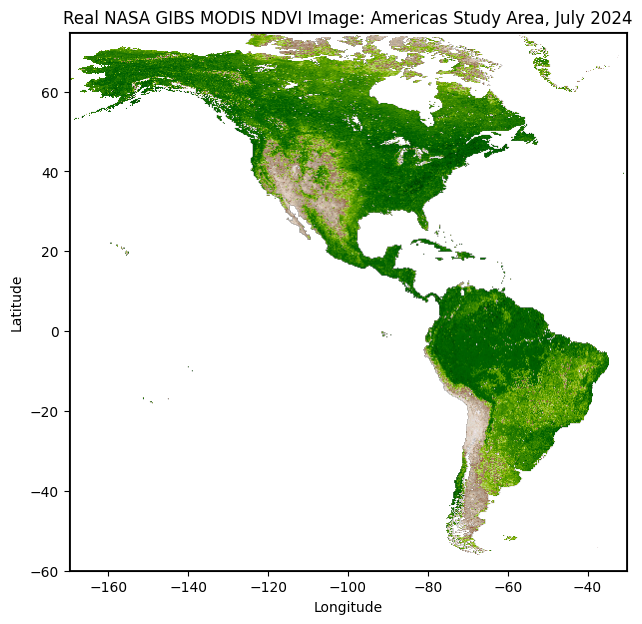

In [18]:
sample_path = fetch_gibs_month(2024, 7)
sample_img = load_image_array(sample_path)

fig, ax = plt.subplots(figsize=(10, 7))
ax.imshow(sample_img, extent=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], origin="upper")
ax.set_title("Real NASA GIBS MODIS NDVI Image: Americas Study Area, July 2024")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.add_patch(Rectangle((LON_MIN, LAT_MIN), LON_MAX - LON_MIN, LAT_MAX - LAT_MIN,
                       fill=False, edgecolor="black", linewidth=2))
plt.show()

# Annual Mean Vegetation Trend

Exploring vegetation proxy in the Americas

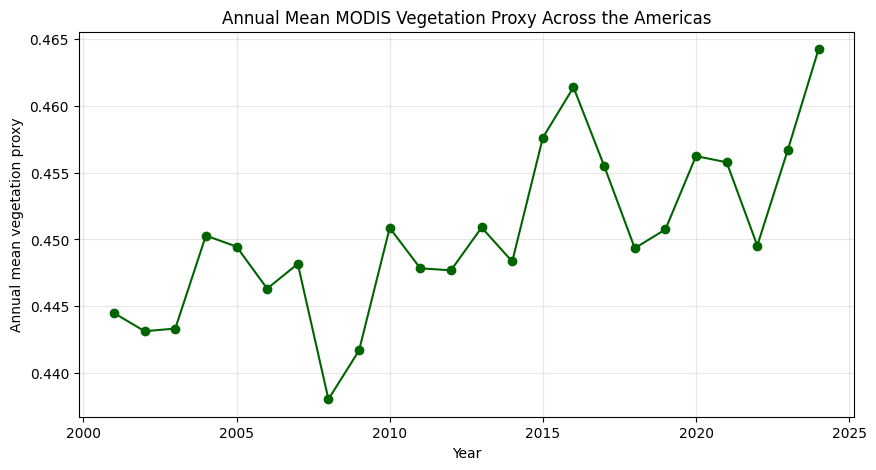

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(annual_mean_df["year"], annual_mean_df["vegetation_proxy"], marker="o", color="darkgreen")
ax.set_title("Annual Mean MODIS Vegetation Proxy Across the Americas")
ax.set_xlabel("Year")
ax.set_ylabel("Annual mean vegetation proxy")
ax.grid(True, alpha=0.3)
plt.show()

# Regional Comparison

Compare vegetation trends across selected regions: Amazon, Western US, Midwest, Central America, Andes, and Canada/Arctic region.

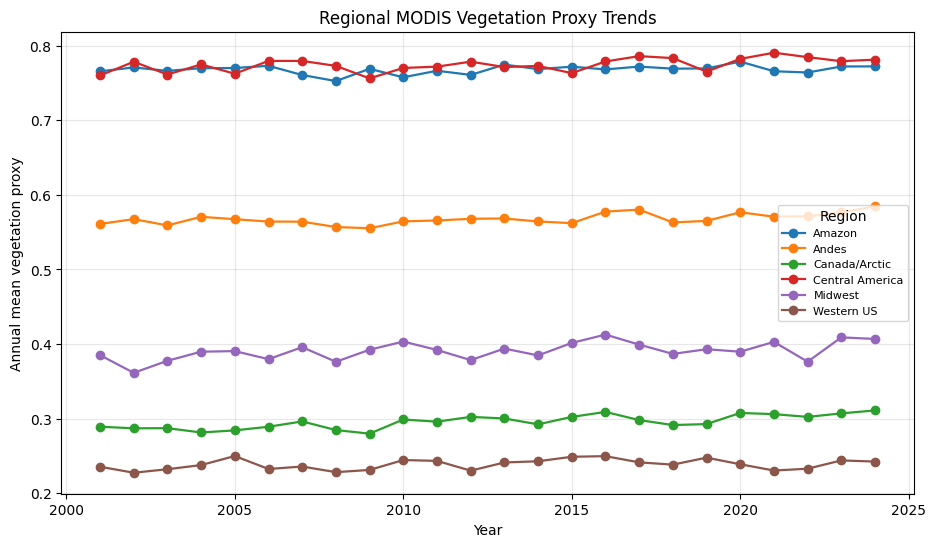

In [20]:
fig, ax = plt.subplots(figsize=(11, 6))
for region_name, region_df in region_trends_df.groupby("region"):
    ax.plot(region_df["year"], region_df["vegetation_proxy"], marker="o", linewidth=1.6, label=region_name)
ax.set_title("Regional MODIS Vegetation Proxy Trends")
ax.set_xlabel("Year")
ax.set_ylabel("Annual mean vegetation proxy")
ax.legend(title="Region", fontsize=8)
ax.grid(True, alpha=0.3)
plt.show()

# Before/After Map

Compares vegetation proxy between 2001-2005 and 2020-2024.

/var/folders/_j/6n25hz191_q4byyqprb75gdm0000gn/T/ipykernel_14729/3322733983.py:1: RuntimeWarning: Mean of empty slice
  baseline_grid = np.nanmean(np.stack([annual_grids[year] for year in BASELINE_YEARS]), axis=0)
/var/folders/_j/6n25hz191_q4byyqprb75gdm0000gn/T/ipykernel_14729/3322733983.py:2: RuntimeWarning: Mean of empty slice
  recent_grid = np.nanmean(np.stack([annual_grids[year] for year in RECENT_YEARS]), axis=0)


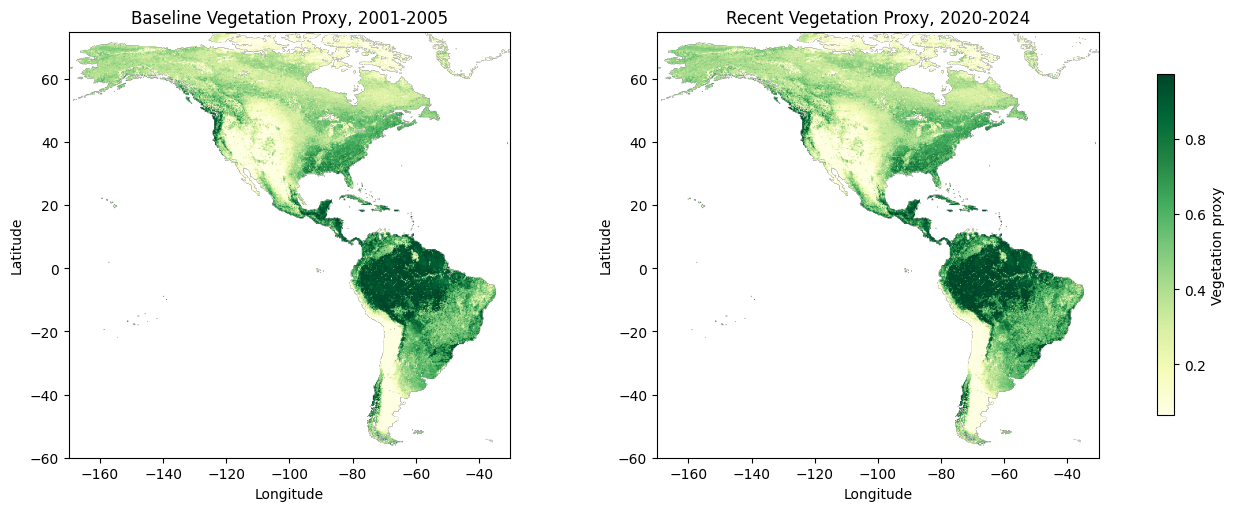

In [21]:
baseline_grid = np.nanmean(np.stack([annual_grids[year] for year in BASELINE_YEARS]), axis=0)
recent_grid = np.nanmean(np.stack([annual_grids[year] for year in RECENT_YEARS]), axis=0)

vmin = np.nanpercentile(np.stack([baseline_grid, recent_grid]), 2)
vmax = np.nanpercentile(np.stack([baseline_grid, recent_grid]), 98)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
im0 = axes[0].imshow(baseline_grid, extent=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], origin="upper", cmap="YlGn", vmin=vmin, vmax=vmax)
axes[0].set_title("Baseline Vegetation Proxy, 2001-2005")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

im1 = axes[1].imshow(recent_grid, extent=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], origin="upper", cmap="YlGn", vmin=vmin, vmax=vmax)
axes[1].set_title("Recent Vegetation Proxy, 2020-2024")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

fig.colorbar(im1, ax=axes, shrink=0.8, label="Vegetation proxy")
plt.show()

# Change/Anomaly Map

See changes of vegetation proxy between 2020-2024 and 2001-2005

Calculation: `vegetation_proxy_2020_2024_mean - vegetation_proxy_2001_2005_mean`.

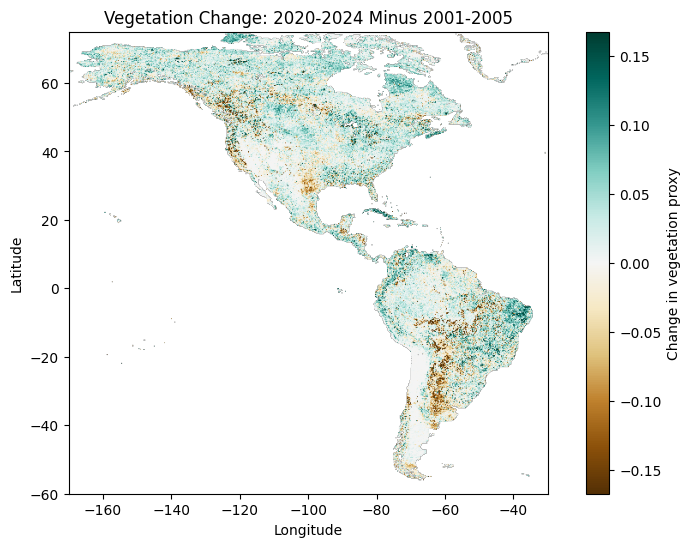

In [22]:
change_grid = recent_grid - baseline_grid
limit = np.nanpercentile(np.abs(change_grid), 98)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(change_grid, extent=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], origin="upper", cmap="BrBG", vmin=-limit, vmax=limit)
ax.set_title("Vegetation Change: 2020-2024 Minus 2001-2005")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
fig.colorbar(im, ax=ax, label="Change in vegetation proxy")
plt.show()

# Regional Change Ranking

Rank selected regions by how much their vegetation proxy changed from the baseline period to the recent period. This directly supports the main question by showing which regions changed most.

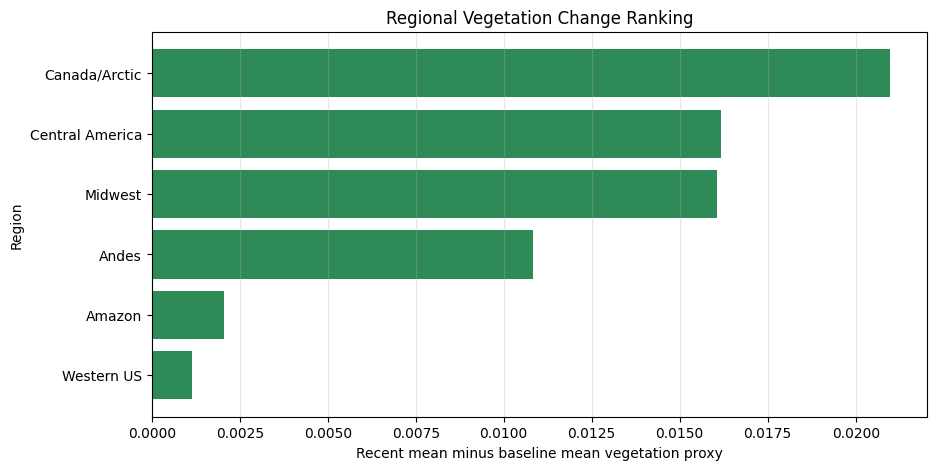

,region,baseline_proxy,recent_proxy,change
5,Western US,0.236713,0.237863,0.001149
0,Amazon,0.768364,0.770405,0.002041
1,Andes,0.565063,0.575893,0.010829
4,Midwest,0.380939,0.397010,0.016070
3,Central America,0.767264,0.783444,0.016180
2,Canada/Arctic,0.285954,0.306924,0.020970


In [24]:
baseline_region = (
    region_trends_df[region_trends_df["year"].isin(BASELINE_YEARS)]
    .groupby("region", as_index=False)["vegetation_proxy"]
    .mean()
    .rename(columns={"vegetation_proxy": "baseline_proxy"})
)
recent_region = (
    region_trends_df[region_trends_df["year"].isin(RECENT_YEARS)]
    .groupby("region", as_index=False)["vegetation_proxy"]
    .mean()
    .rename(columns={"vegetation_proxy": "recent_proxy"})
)
region_change = baseline_region.merge(recent_region, on="region")
region_change["change"] = region_change["recent_proxy"] - region_change["baseline_proxy"]
region_change = region_change.sort_values("change")

colors = np.where(region_change["change"] >= 0, "seagreen", "sienna")

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(region_change["region"], region_change["change"], color=colors)
ax.axvline(0, color="black", linewidth=1.2)
ax.set_title("Regional Vegetation Change Ranking")
ax.set_xlabel("Recent mean minus baseline mean vegetation proxy")
ax.set_ylabel("Region")
ax.grid(True, axis="x", alpha=0.3)
plt.show()

region_change

# 11. Final Visualization Direction

## Greening and Browning of the Americas

**Main question:** Where in the Americas have vegetation patterns changed the most over time?

Planned final D3 interactions:

- timeline scrubber
- play/pause animation
- before/after slider
- region selection
- linked trend chart
- hover tooltips
- annotations for major changes

Planned final data output:

- pre-rendered PNG map frames from real MODIS data
- `environment_frames.json`
- `region_trends.json`
- `metadata.json`

Pre-rendering is useful because satellite rasters are too large for smooth browser interaction. D3 can focus on interaction while Python handles API download, preprocessing, aggregation, and frame export.

# 12. Current Progress

- selected NASA MODIS Terra NDVI as the dataset
- routed real data through the NASA GIBS WMS API
- scoped the project to North and South America
- downloaded/cached monthly NDVI images by year
- aggregated monthly images into annual grids
- created 7 exploratory graphs from real API imagery
- exported checkpoint summaries to `data/processed`
- next step: switch from color-derived GIBS imagery to raw NDVI/EVI values through AppEEARS, LP DAAC, or Earth Engine for the final visualization